In [1]:
import torch
import torchvision
from transformers import AutoModelForImageClassification

import matplotlib.pyplot as plt

from devinterp.optim import SGLD
from devinterp.slt.sampler import estimate_learning_coeff_with_summary
from devinterp.vis_utils import EpsilonBetaAnalyzer


# Local import:
# import sys
# sys.path.append("../src/devinterp")
# from vis_utils import EpsilonBetaAnalyzer


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def evaluate(model, data):
    inputs, outputs = data

    return torch.nn.functional.cross_entropy(model(inputs).logits, outputs), {
        "outputs": outputs
    }


# Load a pretrained MNIST classifier
model = AutoModelForImageClassification.from_pretrained("fxmarty/resnet-tiny-mnist")

model.to(DEVICE)

model.train()

data = torchvision.datasets.MNIST(
    root="../data",
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

batch_size = 256

loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)

/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


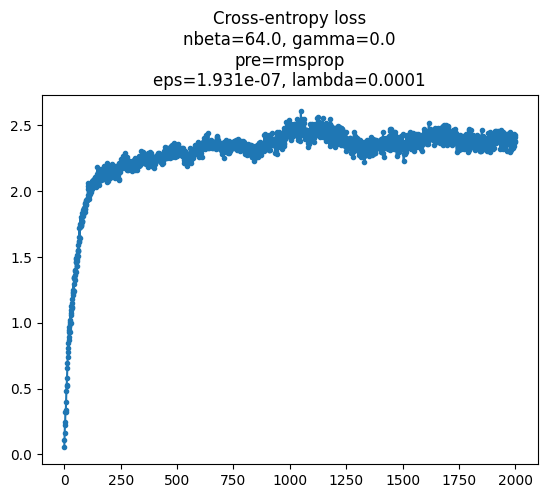

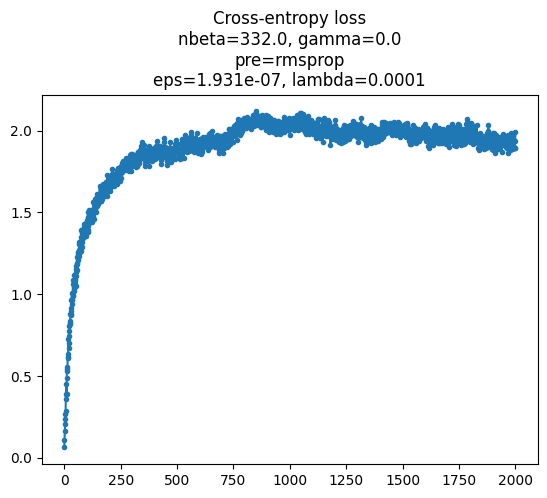

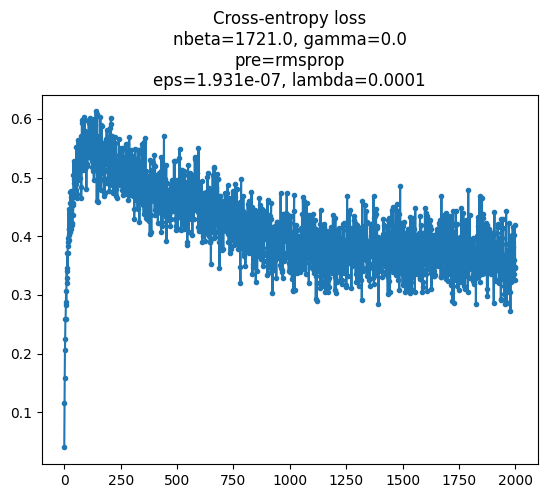

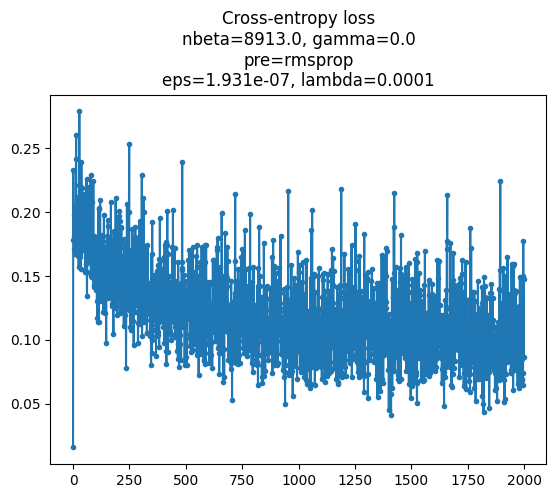

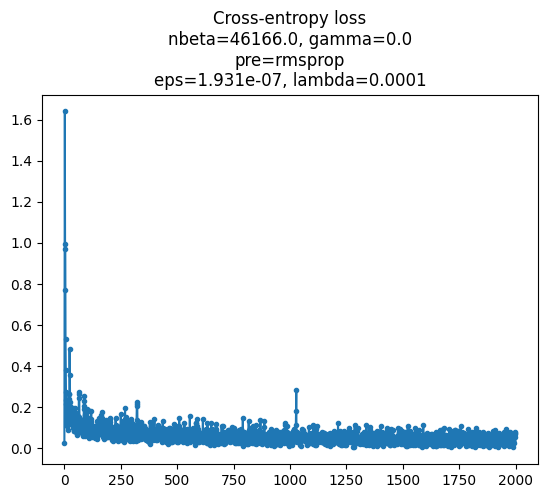

In [25]:
from palamedes.sgld_sampler import *

for nbeta in [64., 332., 1721., 8913., 46166.,]:

    gamma = 0.

    preconditioner = "rmsprop"

    params = SGLDParams(
        eps=0.00019306977288832496 / 1e3,  # total step size
        gamma=gamma,  # localization term
        batch_size=batch_size,  # batch size
        nbeta=nbeta,  # this is not beta, but beta * n, where n= |whole dataset|
        num_steps=2000,  # number of steps
        checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
        save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
        # device=device,
        preconditioner=preconditioner,  # "none" or "rmsprop"
        alpha_rmsprop=0.99,  # rmsprop parameter
        lambda_rmsprop=1e-4,  # rmsprop parameter
    )

    sgld_dict = sgld(
        model,
        params,
        dataset=loader,
        cost_fn="cross_entropy",
        device=DEVICE,
        fp16=False,
    )

    plt.plot(sgld_dict['loss'], '.-')
    plt.title(f"Cross-entropy loss\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}")
    plt.show()

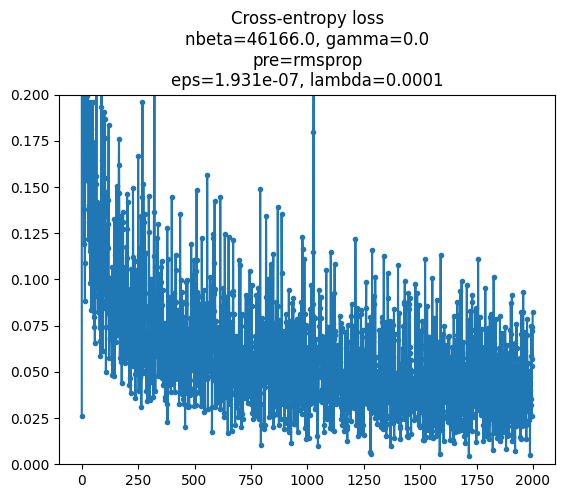

In [30]:

plt.plot(sgld_dict['loss'], '.-')
plt.ylim(0, .2)
plt.title(f"Cross-entropy loss\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}")
plt.show()

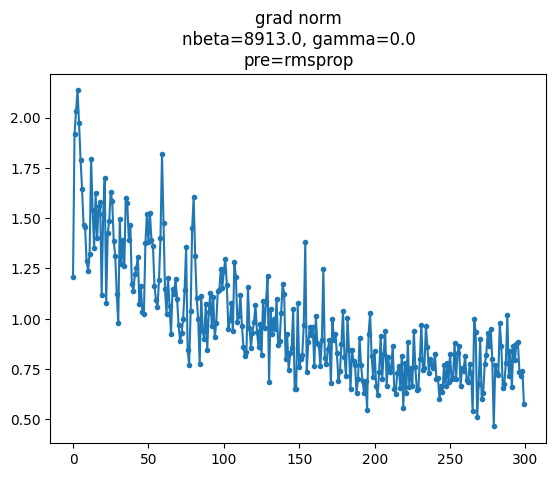

In [24]:

plt.plot(sgld_dict['gradient_norm'], '.-')
plt.title(f"grad norm\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}")
plt.show()

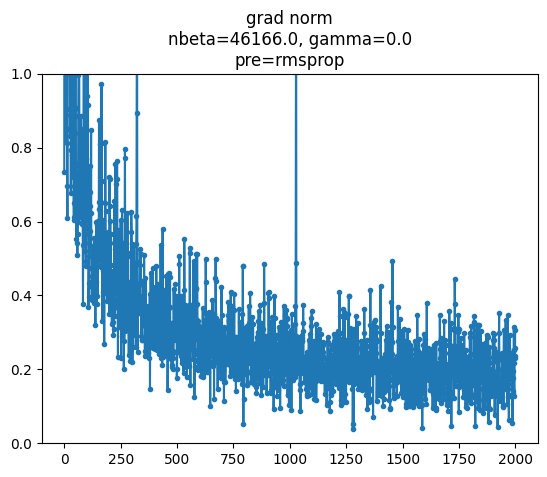

In [28]:

plt.plot(sgld_dict['gradient_norm'], '.-')
plt.ylim(0, 1)
plt.title(f"grad norm\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}")
plt.show()

In [20]:
.5 / torch.sqrt(torch.tensor(184074))

tensor(0.0012)

In [26]:
sgld_dict['gradient_norm'][-10:]

[0.1353064775466919,
 0.17641671001911163,
 0.2173769176006317,
 0.3145579397678375,
 0.25368914008140564,
 0.12876255810260773,
 0.2580990195274353,
 0.23735414445400238,
 0.2297629565000534,
 0.30665603280067444]

In [15]:
torch.norm(torch.ones(184074))

tensor(429.0385)

In [17]:
torch.sqrt(torch.tensor(184074))

tensor(429.0385)

In [14]:
torch.nn.utils.parameters_to_vector(model.parameters()).shape

torch.Size([184074])